<a href="https://colab.research.google.com/github/NomeCoder/LiC6-based-battery/blob/main/LIC6vsLiAl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q qiskit qiskit-algorithms qiskit-nature pyscf

Qiskit: 2.4.2
All libraries installed successfully!


In [3]:
pip install pylatexenc

In [4]:
!pip -q install py3Dmol

In [5]:
# Atomic structure tools
!pip -q install ase

# Density Functional Theory (DFT)
!pip -q install gpaw gpaw-data

# Visualization
!pip -q install nglview py3Dmol matplotlib plotly

# Scientific libraries
!pip -q install scipy numpy pandas

# Crystal structure database
!pip -q install pymatgen mp-api

Retrieving SummaryDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]


=========== STABILITY ===========
Material ID: mp-1001581
Formula: LiC6
Formation Energy per Atom: -0.03471635952380885 eV/atom
Energy Above Hull: 0.0004901294805179646 eV/atom
Status : Nearly Stable


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Downloaded LiC6 structure.
Atoms(symbols='LiC6', pbc=True, cell=[[3.6495039, 0.0, 0.0], [0.0, 4.30693209, 0.0], [0.0, -2.1534659108955325, 3.7299126797396536]], spacegroup_kinds=...)


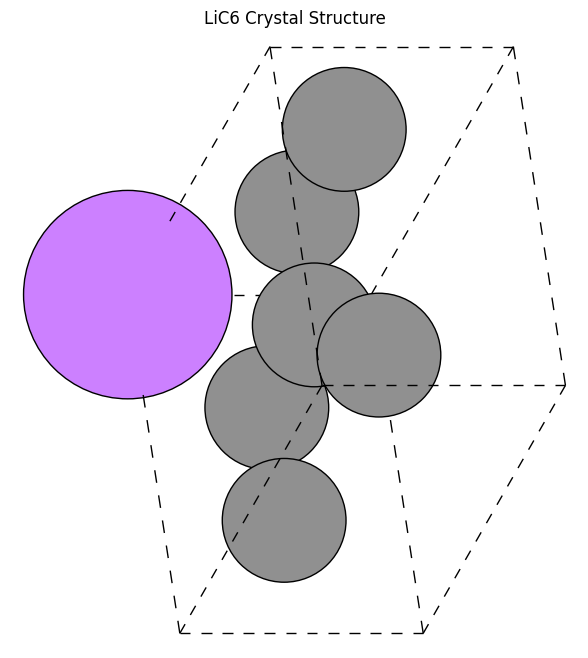


Ground State Energy
-48.30304944905306 eV


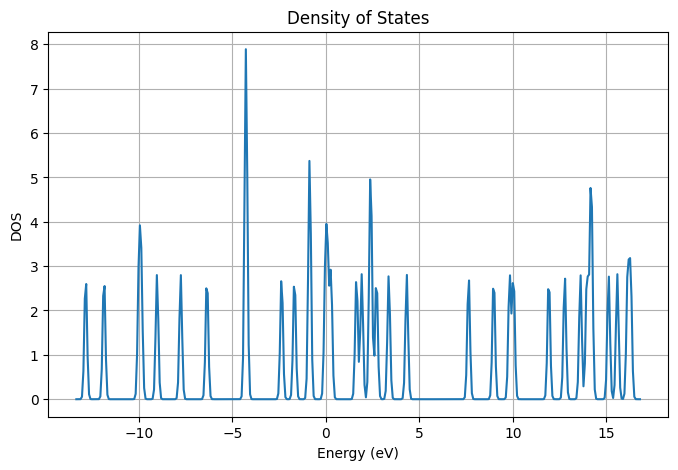

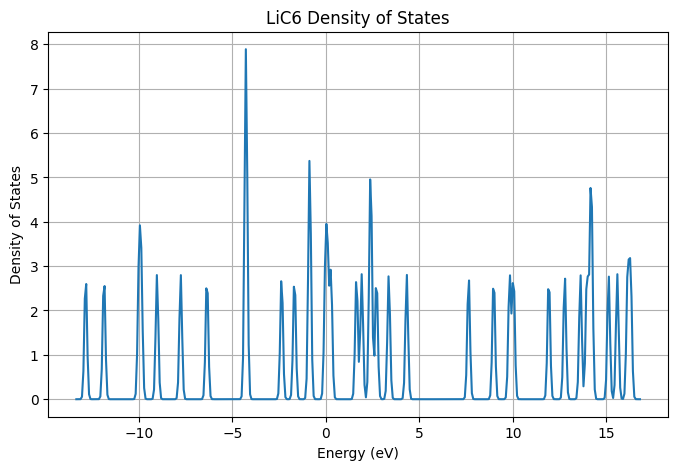

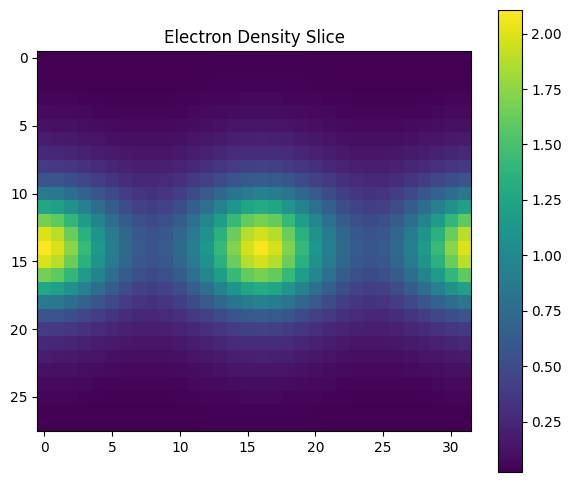


=========== SUMMARY ===========
Material : LiC6
Ground State Energy : -48.30304944905306 eV
Formation Energy : -0.03471635952380885 eV/atom
Energy Above Hull : 0.0004901294805179646 eV/atom
Nearly Stable


In [6]:
# ============================================================
# LiC6 Battery Material Simulation (Google Colab)
# ============================================================

# Install libraries
!pip -q install ase gpaw gpaw-data pymatgen mp-api nglview matplotlib

import matplotlib.pyplot as plt

from mp_api.client import MPRester
from ase.visualize.plot import plot_atoms
from ase.io import read

from gpaw import GPAW, PW

# ============================================================
# YOUR MATERIALS PROJECT API KEY
# ============================================================

API_KEY = "4QseSmzHkpBY2f2XBVGPYxLwDh7jM9Go"

# ============================================================
# Download LiC6 crystal
# ============================================================

# ============================================================
# Formation Energy & Stability
# ============================================================

with MPRester(API_KEY) as mpr:

    docs = mpr.materials.summary.search(
        formula="LiC6"
    )

    doc = docs[0]

    print("\n=========== STABILITY ===========")

    print("Material ID:", doc.material_id)

    print("Formula:", doc.formula_pretty)

    print("Formation Energy per Atom:",
          doc.formation_energy_per_atom,
          "eV/atom")

    print("Energy Above Hull:",
          doc.energy_above_hull,
          "eV/atom")

    if doc.energy_above_hull == 0:
        print("Status : Thermodynamically Stable")
    elif doc.energy_above_hull < 0.05:
        print("Status : Nearly Stable")
    else:
        print("Status : Metastable")

    print("===============================")

    structure = mpr.get_structure_by_material_id(doc.material_id)

structure.to("LiC6.cif")

print("Downloaded LiC6 structure.")

# ============================================================
# Load with ASE
# ============================================================

atoms = read("LiC6.cif")

print(atoms)

# ============================================================
# 3D Crystal Visualization
# ============================================================

fig, ax = plt.subplots(figsize=(8,8))

plot_atoms(
    atoms,
    ax,
    rotation=('45x,35y')
)

plt.title("LiC6 Crystal Structure")

plt.show()

# ============================================================
# Run DFT
# ============================================================

calc = GPAW(
    mode=PW(250),     # lower cutoff
    xc="PBE",
    kpts=(2,2,2),     # fewer k-points
    txt="gpaw_output.txt"
)

atoms.calc = calc

energy = atoms.get_potential_energy()

print("\n===================================")
print("Ground State Energy")
print(energy,"eV")
print("===================================")

# ============================================================
# Density of States
# ============================================================

energies, values = calc.get_dos(npts=400)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(energies, values)
plt.xlabel("Energy (eV)")
plt.ylabel("DOS")
plt.title("Density of States")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    energies,
    values
)

plt.xlabel("Energy (eV)")
plt.ylabel("Density of States")

plt.title("LiC6 Density of States")

plt.grid()

plt.show()

# ============================================================
# Electron Density
# ============================================================

density = calc.get_all_electron_density()

plt.figure(figsize=(7,6))

plt.imshow(
    density[:,:,density.shape[2]//2],
    cmap="viridis"
)

plt.colorbar()

plt.title("Electron Density Slice")

plt.show()

# ============================================================
# Final Summary
# ============================================================

print("\n=========== SUMMARY ===========")

print("Material :", doc.formula_pretty)

print("Ground State Energy :", energy, "eV")

print("Formation Energy :", doc.formation_energy_per_atom, "eV/atom")

print("Energy Above Hull :", doc.energy_above_hull, "eV/atom")

if doc.energy_above_hull == 0:
    print("Thermodynamically Stable")
elif doc.energy_above_hull < 0.05:
    print("Nearly Stable")
else:
    print("Metastable")

print("===============================")

Retrieving SummaryDoc documents:   0%|          | 0/3 [00:00<?, ?it/s]


=========== STABILITY ===========
Material ID: mp-1079240
Formula: LiAl
Formation Energy per Atom: -0.12185767833333383 eV/atom
Energy Above Hull: 0.08662110999999939 eV/atom
Status : Metastable


Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

Downloaded LiAl structure.
Atoms(symbols='Li4Al4', pbc=True, cell=[[4.4680018, 0.0, 0.0], [-2.2340006953725107, 3.8694031810963274, 0.0], [0.0, 0.0, 8.604099]], spacegroup_kinds=...)


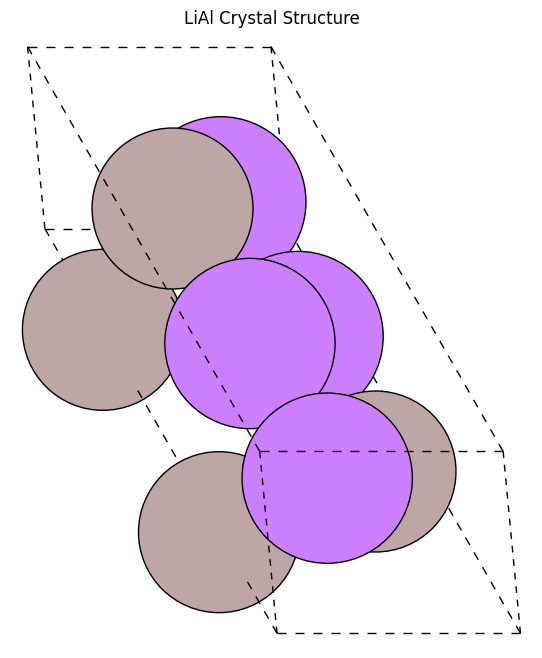

In [ ]:
# ============================================================
# LiAl Battery Material Simulation (Google Colab)
# ============================================================

# Install libraries
!pip -q install ase gpaw gpaw-data pymatgen mp-api nglview matplotlib

import matplotlib.pyplot as plt

from mp_api.client import MPRester
from ase.visualize.plot import plot_atoms
from ase.io import read

from gpaw import GPAW, PW

# ============================================================
# YOUR MATERIALS PROJECT API KEY
# ============================================================

API_KEY = "4QseSmzHkpBY2f2XBVGPYxLwDh7jM9Go"

# ============================================================
# Download LiAl crystal
# ============================================================

# ============================================================
# Formation Energy & Stability
# ============================================================

with MPRester(API_KEY) as mpr:

    docs = mpr.materials.summary.search(
        formula="LiAl"
    )

    doc = docs[0]

    print("\n=========== STABILITY ===========")

    print("Material ID:", doc.material_id)

    print("Formula:", doc.formula_pretty)

    print("Formation Energy per Atom:",
          doc.formation_energy_per_atom,
          "eV/atom")

    print("Energy Above Hull:",
          doc.energy_above_hull,
          "eV/atom")

    if doc.energy_above_hull == 0:
        print("Status : Thermodynamically Stable")
    elif doc.energy_above_hull < 0.05:
        print("Status : Nearly Stable")
    else:
        print("Status : Metastable")

    print("===============================")

    structure = mpr.get_structure_by_material_id(doc.material_id)

structure.to("LiAl.cif")

print("Downloaded LiAl structure.")

# ============================================================
# Load with ASE
# ============================================================

atoms = read("LiAl.cif")

print(atoms)

# ============================================================
# 3D Crystal Visualization
# ============================================================

fig, ax = plt.subplots(figsize=(8,8))

plot_atoms(
    atoms,
    ax,
    rotation=('45x,35y')
)

plt.title("LiAl Crystal Structure")

plt.show()

# ============================================================
# Run DFT
# ============================================================

calc = GPAW(
    mode=PW(250),     # lower cutoff
    xc="PBE",
    kpts=(2,2,2),     # fewer k-points
    txt="gpaw_output.txt"
)

atoms.calc = calc

energy = atoms.get_potential_energy()

print("\n===================================")
print("Ground State Energy")
print(energy,"eV")
print("===================================")

# ============================================================
# Density of States
# ============================================================

energies, values = calc.get_dos(npts=400)

plt.figure(figsize=(8,5))
plt.plot(energies, values)
plt.xlabel("Energy (eV)")
plt.ylabel("DOS")
plt.title("Density of States")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))

plt.plot(
    energies,
    values
)

plt.xlabel("Energy (eV)")
plt.ylabel("Density of States")

plt.title("LiAl Density of States")

plt.grid()

plt.show()

# ============================================================
# Electron Density
# ============================================================

density = calc.get_all_electron_density()

plt.figure(figsize=(7,6))

plt.imshow(
    density[:,:,density.shape[2]//2],
    cmap="viridis"
)

plt.colorbar()

plt.title("Electron Density Slice")

plt.show()

# ============================================================
# Final Summary
# ============================================================

print("\n=========== SUMMARY ===========")

print("Material :", doc.formula_pretty)

print("Ground State Energy :", energy, "eV")

print("Formation Energy :", doc.formation_energy_per_atom, "eV/atom")

print("Energy Above Hull :", doc.energy_above_hull, "eV/atom")

if doc.energy_above_hull == 0:
    print("Thermodynamically Stable")
elif doc.energy_above_hull < 0.05:
    print("Nearly Stable")
else:
    print("Metastable")

print("===============================")